# Training curves + error analysis (Siamese verification)
This notebook expects your training script to write:
- `metrics.jsonl` (one JSON per epoch: train/val loss+acc)
- `val_predictions.parquet` (or `.csv`) with per-pair predictions for error analysis


In [17]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR = Path(r"D:/Projects/Facial_Recognition")
# Point this at your run folder (the same --workdir you used in training)
workdir = PROJECT_DIR / "outputs"  # change if needed

metrics_path = workdir / "metrics.jsonl"

# Optional: per-pair prediction dumps for error analysis
val_pred_path_parquet = workdir / "val_predictions.parquet"
val_pred_path_csv = workdir / "val_predictions.csv"


## Load `metrics.jsonl` and plot train/val curves


In [18]:
rows = []
with metrics_path.open("r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        rows.append(json.loads(line))

df = pd.DataFrame(rows).sort_values("epoch").reset_index(drop=True)
df

,epoch,train_loss,train_acc,val_loss,val_acc,lr,momentum
0,1,0.694487,0.480909,0.691630,0.494545,0.010000,0.500
1,2,0.690994,0.504545,0.690438,0.495455,0.009900,0.525
2,3,0.688970,0.499091,0.689320,0.496364,0.009801,0.550
3,4,0.686920,0.509091,0.688540,0.517273,0.009703,0.575
4,5,0.684131,0.545455,0.687102,0.510909,0.009606,0.600
5,6,0.680421,0.542727,0.686094,0.525455,0.009510,0.625
6,7,0.678393,0.552727,0.685358,0.534545,0.009415,0.650
7,8,0.676748,0.567273,0.684245,0.535455,0.009321,0.675
8,9,0.673207,0.579091,0.682539,0.528182,0.009227,0.700
9,10,0.668212,0.600000,0.680704,0.529091,0.009135,0.725


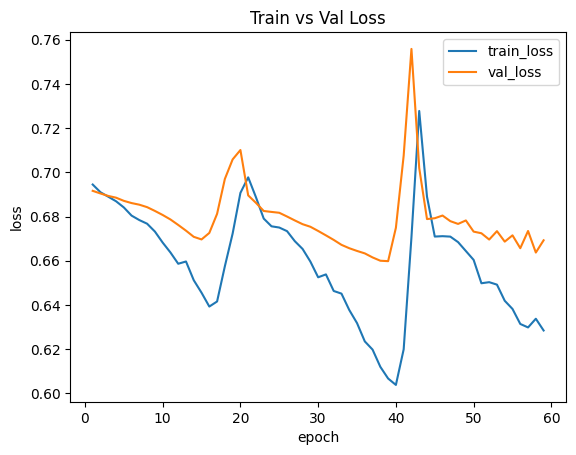

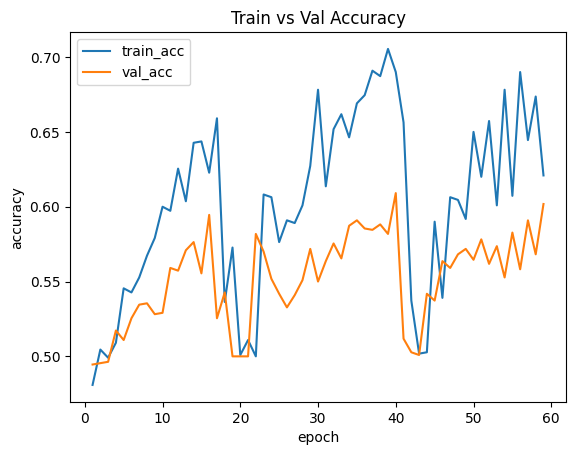

In [19]:
# --- Plot losses together ---
plt.figure()
plt.plot(df["epoch"], df["train_loss"], label="train_loss")
plt.plot(df["epoch"], df["val_loss"], label="val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.title("Train vs Val Loss")
plt.show()

# --- Plot accuracies together ---
plt.figure()
plt.plot(df["epoch"], df["train_acc"], label="train_acc")
plt.plot(df["epoch"], df["val_acc"], label="val_acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.title("Train vs Val Accuracy")
plt.show()


## Load per-pair predictions (val) for error analysis
Expected columns (minimum):
- `epoch` (int)
- `y_true` (0/1)
- `p_same` (float in [0,1])
Recommended additional columns:
- `path1`, `path2` (strings)
- `loss` (per-sample BCE)


In [20]:
val_pred_path_csv = workdir / "val_predictions.csv"
val_pred_path_parquet = workdir / "val_predictions.parquet"

if val_pred_path_csv.exists():
    pred = pd.read_csv(val_pred_path_csv)
elif val_pred_path_parquet.exists():
    pred = pd.read_parquet(val_pred_path_parquet)
else:
    raise FileNotFoundError("No val_predictions.csv or val_predictions.parquet found.")

pred = pred.copy()
pred["y_true"] = pred["y_true"].astype(int)
pred["p_same"] = pred["p_same"].astype(float)
pred["y_pred_05"] = (pred["p_same"] >= 0.5).astype(int)

pred.head()


,epoch,y_true,p_same,loss,path1,path2,y_pred_05
0,42,1,0.511152,0.671089,D:\Projects\Facial_Recognition\images\Gloria_A...,D:\Projects\Facial_Recognition\images\Gloria_A...,1
1,42,1,0.492299,0.708670,D:\Projects\Facial_Recognition\images\Lisa_Got...,D:\Projects\Facial_Recognition\images\Lisa_Got...,0
2,42,1,0.521852,0.650370,D:\Projects\Facial_Recognition\images\Pupi_Ava...,D:\Projects\Facial_Recognition\images\Pupi_Ava...,1
3,42,0,0.474576,0.643549,D:\Projects\Facial_Recognition\images\Ahmed_Ib...,D:\Projects\Facial_Recognition\images\Audrey_L...,0
4,42,0,0.496378,0.685928,D:\Projects\Facial_Recognition\images\Ahmed_Ib...,D:\Projects\Facial_Recognition\images\Eric_Chr...,0


### 1) Confusion matrix at threshold=0.5 (by epoch)


In [21]:
def confusion_counts(df_epoch: pd.DataFrame):
    y = df_epoch["y_true"].to_numpy()
    yhat = df_epoch["y_pred_05"].to_numpy()
    tp = int(((y == 1) & (yhat == 1)).sum())
    tn = int(((y == 0) & (yhat == 0)).sum())
    fp = int(((y == 0) & (yhat == 1)).sum())
    fn = int(((y == 1) & (yhat == 0)).sum())
    return tp, tn, fp, fn

summary = []
for ep, g in pred.groupby("epoch"):
    tp, tn, fp, fn = confusion_counts(g)
    acc = (tp + tn) / max(1, (tp + tn + fp + fn))
    summary.append({"epoch": int(ep), "tp": tp, "tn": tn, "fp": fp, "fn": fn, "acc@0.5": acc})

cm_df = pd.DataFrame(summary).sort_values("epoch").reset_index(drop=True)
cm_df


,epoch,tp,tn,fp,fn,acc@0.5
0,42,407,250,300,143,0.597273


### 2) Score distributions (positives vs negatives)


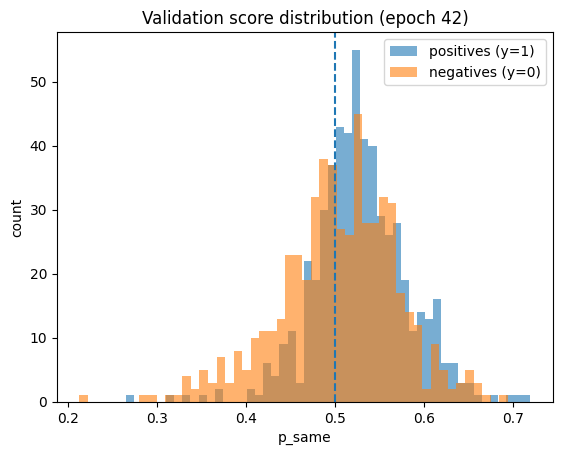

In [22]:
last_epoch = int(pred["epoch"].max())
g = pred[pred["epoch"] == last_epoch]

pos = g[g["y_true"] == 1]["p_same"].to_numpy()
neg = g[g["y_true"] == 0]["p_same"].to_numpy()

plt.figure()
plt.hist(pos, bins=50, alpha=0.6, label="positives (y=1)")
plt.hist(neg, bins=50, alpha=0.6, label="negatives (y=0)")
plt.axvline(0.5, linestyle="--")
plt.xlabel("p_same")
plt.ylabel("count")
plt.title(f"Validation score distribution (epoch {last_epoch})")
plt.legend()
plt.show()


### 3) Hardest mistakes: top false positives / false negatives


In [23]:
def top_mistakes(df_epoch: pd.DataFrame, k: int = 20):
    fp = df_epoch[(df_epoch["y_true"] == 0) & (df_epoch["y_pred_05"] == 1)].copy()
    fn = df_epoch[(df_epoch["y_true"] == 1) & (df_epoch["y_pred_05"] == 0)].copy()

    # "Most wrong" at threshold=0.5:
    # - FP: probability very high while y=0
    # - FN: probability very low while y=1
    fp = fp.sort_values("p_same", ascending=False).head(k)
    fn = fn.sort_values("p_same", ascending=True).head(k)
    return fp, fn

fp_top, fn_top = top_mistakes(g, k=20)

print("Top false positives:")
display(fp_top[["p_same","y_true","path1","path2","loss"]].head(10) if "path1" in fp_top.columns else fp_top.head(10))

print("\nTop false negatives:")
display(fn_top[["p_same","y_true","path1","path2","loss"]].head(10) if "path1" in fn_top.columns else fn_top.head(10))


Top false positives:


,p_same,y_true,path1,path2,loss
228,0.693891,0,D:\Projects\Facial_Recognition\images\Mariah_C...,D:\Projects\Facial_Recognition\images\Richard_...,1.183815
830,0.670512,0,D:\Projects\Facial_Recognition\images\Dan_Boyl...,D:\Projects\Facial_Recognition\images\Pete_Gil...,1.110216
574,0.663922,0,D:\Projects\Facial_Recognition\images\Joe_Calz...,D:\Projects\Facial_Recognition\images\Joerg_Ha...,1.090411
46,0.660556,0,D:\Projects\Facial_Recognition\images\DAngelo_...,D:\Projects\Facial_Recognition\images\Wendy_Ke...,1.080447
1098,0.657661,0,D:\Projects\Facial_Recognition\images\Matt_And...,D:\Projects\Facial_Recognition\images\Pauley_P...,1.071953
52,0.648190,0,D:\Projects\Facial_Recognition\images\Keith_Bi...,D:\Projects\Facial_Recognition\images\Shaun_Po...,1.044664
804,0.646937,0,D:\Projects\Facial_Recognition\images\Paola_Es...,D:\Projects\Facial_Recognition\images\Ranil_Wi...,1.041109
234,0.646379,0,D:\Projects\Facial_Recognition\images\John_Rei...,D:\Projects\Facial_Recognition\images\Jose_Can...,1.039530
873,0.645942,0,D:\Projects\Facial_Recognition\images\Afton_Sm...,D:\Projects\Facial_Recognition\images\Mario_Lo...,1.038296
98,0.645895,0,D:\Projects\Facial_Recognition\images\Dave_Wil...,D:\Projects\Facial_Recognition\images\Robin_Mc...,1.038162



Top false negatives:


,p_same,y_true,path1,path2,loss
223,0.265192,1,D:\Projects\Facial_Recognition\images\Andy_Rod...,D:\Projects\Facial_Recognition\images\Andy_Rod...,1.327302
424,0.310972,1,D:\Projects\Facial_Recognition\images\Tiger_Wo...,D:\Projects\Facial_Recognition\images\Tiger_Wo...,1.168051
775,0.331520,1,D:\Projects\Facial_Recognition\images\David_We...,D:\Projects\Facial_Recognition\images\David_We...,1.104069
457,0.347633,1,D:\Projects\Facial_Recognition\images\Queen_El...,D:\Projects\Facial_Recognition\images\Queen_El...,1.056608
184,0.366248,1,D:\Projects\Facial_Recognition\images\Martin_S...,D:\Projects\Facial_Recognition\images\Martin_S...,1.004446
931,0.370368,1,D:\Projects\Facial_Recognition\images\Nick_Nol...,D:\Projects\Facial_Recognition\images\Nick_Nol...,0.993257
899,0.404132,1,D:\Projects\Facial_Recognition\images\Kate_Win...,D:\Projects\Facial_Recognition\images\Kate_Win...,0.906013
739,0.409290,1,D:\Projects\Facial_Recognition\images\Muhammad...,D:\Projects\Facial_Recognition\images\Muhammad...,0.893332
732,0.419350,1,D:\Projects\Facial_Recognition\images\Luiz_Ina...,D:\Projects\Facial_Recognition\images\Luiz_Ina...,0.869050
900,0.419907,1,D:\Projects\Facial_Recognition\images\Kate_Win...,D:\Projects\Facial_Recognition\images\Kate_Win...,0.867723


### 4) (Optional) Visualize a few mistaken pairs
Works if `path1`/`path2` point to real image files on your machine.


FP #1: p_same=0.694 y_true=0 loss=1.1838


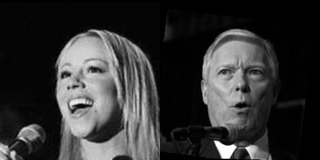

FP #2: p_same=0.671 y_true=0 loss=1.1102


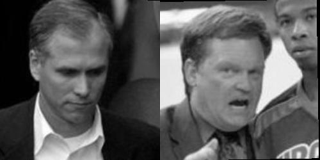

FP #3: p_same=0.664 y_true=0 loss=1.0904


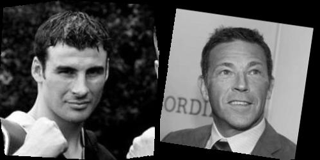

FP #4: p_same=0.661 y_true=0 loss=1.0804


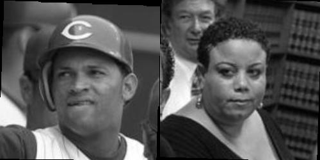

FP #5: p_same=0.658 y_true=0 loss=1.0720


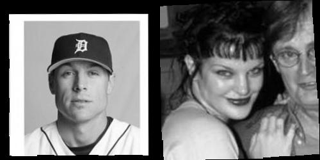

FN #1: p_same=0.265 y_true=1 loss=1.3273


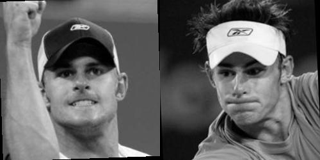

FN #2: p_same=0.311 y_true=1 loss=1.1681


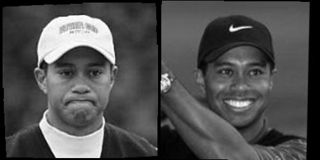

FN #3: p_same=0.332 y_true=1 loss=1.1041


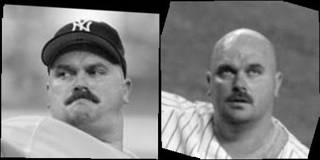

FN #4: p_same=0.348 y_true=1 loss=1.0566


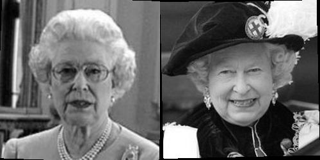

FN #5: p_same=0.366 y_true=1 loss=1.0044


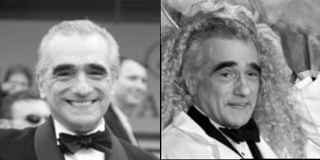

In [24]:
from PIL import Image

def show_pair(row, size=(160, 160)):
    p1 = Path(row["path1"])
    p2 = Path(row["path2"])
    im1 = Image.open(p1).convert("RGB").resize(size)
    im2 = Image.open(p2).convert("RGB").resize(size)
    canvas = Image.new("RGB", (size[0]*2, size[1]))
    canvas.paste(im1, (0,0))
    canvas.paste(im2, (size[0],0))
    return canvas

# Show a few examples (edit indices as you wish)
if "path1" in fp_top.columns and len(fp_top) > 0:
    for i in range(min(5, len(fp_top))):
        row = fp_top.iloc[i]
        print(f"FP #{i+1}: p_same={row['p_same']:.3f} y_true={row['y_true']} loss={row.get('loss', np.nan):.4f}")
        display(show_pair(row))

if "path1" in fn_top.columns and len(fn_top) > 0:
    for i in range(min(5, len(fn_top))):
        row = fn_top.iloc[i]
        print(f"FN #{i+1}: p_same={row['p_same']:.3f} y_true={row['y_true']} loss={row.get('loss', np.nan):.4f}")
        display(show_pair(row))
